# InstanSeg tiled inference: resolved versus unresolved

This notebook asks one question: when `resolve_cell_and_nucleus=False`, are nuclei still lost during medium-mode tiled inference?

It runs the same crop and settings four times:

- patched InstanSeg with resolution on and off
- frozen reference InstanSeg with resolution on and off

The comparison uses nuclear and cell foreground, instance counts, and simple overlays. Watershed is not included.

In [6]:
from pathlib import Path
import json, os, re, subprocess, sys, tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.segmentation import find_boundaries
import tifffile
import torch

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
PATCHED_ROOT = (REPO_ROOT.parent / 'instanseg').resolve()
REFERENCE_ROOT = (REPO_ROOT / 'Reference/instanseg-main').resolve()
MODEL_CACHE = Path('/data1/lowes/ratnayn/conda_envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/bioimageio_models')
ARTIFACT_DIR = REPO_ROOT / 'experimental_data/instanseg_watershed_reconciliation'
RUN_INFERENCE = True  # Set True on a GPU allocation, then run all cells.

MODEL = 'fluorescence_nuclei_and_cells'
CHANNELS = [
    'R1_DAPI', 'R4_P19_POLYRAT', 'R4_GFP_POLY_AF488',
    'R6_CD45_CST_AF647', 'R6_PANCK_AE1_AE3_750', 'R12_CD31_D8V9E_AF750',
    'R7_NAK_ATPASE_555', 'R8_F480_D2S9R_555', 'R9_CD68_E3O7V_488',
    'R12_CD3E_E4T1B_AF555',
]
SETTINGS = {
    'pixel_size': 0.325, 'tile_size': 512, 'batch_size': 4,
    'normalise': True, 'normalisation_subsampling_factor': 1,
    'rescale_output': True, 'return_image_tensor': False,
    'min_size': 10, 'mask_threshold': 0.53, 'peak_distance': 5,
    'seed_threshold': 0.7, 'overlap_threshold': 0.3,
    'mean_threshold': 0.0, 'fg_threshold': 0.5,
    'window_size': 32, 'cleanup_fragments': True,
}

crops = sorted(ARTIFACT_DIR.glob('SLIDE-0330_C2_A_1L_x24618_y40257_w2048_h2048_instanseg11ch_*.ome.tif'))
if not crops:
    raise FileNotFoundError(f'No test crop found in {ARTIFACT_DIR}')
CROP = crops[-1]

for path in [PATCHED_ROOT / 'instanseg/utils/tiling.py', REFERENCE_ROOT / 'instanseg/utils/tiling.py', CROP]:
    if not path.exists():
        raise FileNotFoundError(path)
patch_text = (PATCHED_ROOT / 'instanseg/utils/tiling.py').read_text()
assert 'nuclei_map_list = map_list if labels_are_matched else None' in patch_text

print('patched source:', PATCHED_ROOT)
print('reference source:', REFERENCE_ROOT)
print('crop:', CROP)
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')

patched source: /data1/lowes/ratnayn/Codex/projects/instanseg
reference source: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/Reference/instanseg-main
crop: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_reconciliation/SLIDE-0330_C2_A_1L_x24618_y40257_w2048_h2048_instanseg11ch_ebc14fe0.ome.tif
CUDA: True NVIDIA H200 NVL


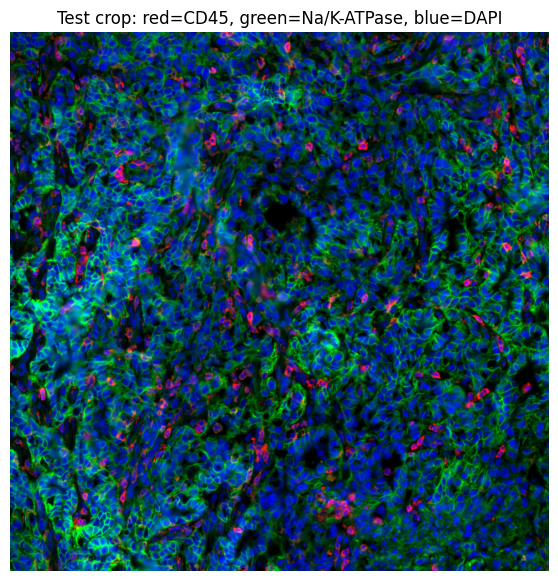

In [7]:
def channel_names(ome_xml):
    return re.findall(r'<Channel[^>]*Name="([^"]+)"', ome_xml or '')

def robust01(image):
    lo, hi = np.percentile(image, (1, 99.8))
    return np.clip((image.astype(np.float32) - lo) / max(float(hi - lo), 1e-6), 0, 1)

with tifffile.TiffFile(CROP) as tf:
    names = channel_names(tf.ome_metadata)
    indices = {name: i for i, name in enumerate(names)}
    missing = [name for name in CHANNELS if name not in indices]
    if missing:
        raise ValueError(f'Missing channels: {missing}')
    image = np.stack([tf.series[0].pages[indices[name]].asarray() for name in CHANNELS])

rgb = np.stack([
    robust01(image[CHANNELS.index('R6_CD45_CST_AF647')]),
    robust01(image[CHANNELS.index('R7_NAK_ATPASE_555')]),
    robust01(image[CHANNELS.index('R1_DAPI')]),
], axis=-1) ** 0.7

plt.figure(figsize=(7, 7))
plt.imshow(rgb)
plt.title('Test crop: red=CD45, green=Na/K-ATPase, blue=DAPI')
plt.axis('off'); plt.show()

## Run resolved and unresolved inference

Each source runs in its own Python process so the two `instanseg` packages cannot be mixed. The only inference argument changed within a source is `resolve_cell_and_nucleus`.

In [8]:
INFERENCE_PROGRAM = r'''
import json, re, sys
import numpy as np
import tifffile
from instanseg import InstanSeg

crop, output_path, model_name, channels_json, settings_json = sys.argv[1:6]
channels, settings = json.loads(channels_json), json.loads(settings_json)
with tifffile.TiffFile(crop) as tf:
    names = re.findall(r'<Channel[^>]*Name="([^"]+)"', tf.ome_metadata or '')
    indices = {name: i for i, name in enumerate(names)}
    image = np.stack([tf.series[0].pages[indices[name]].asarray() for name in channels]).astype(np.float32, copy=False)
model = InstanSeg(model_name, verbosity=1)
outputs = {}
for name, resolve in [('resolved', True), ('unresolved', False)]:
    value = model.eval_medium_image(image, resolve_cell_and_nucleus=resolve, **settings)
    outputs[name] = value.detach().cpu().numpy().astype(np.uint32, copy=False)
    print(name, outputs[name].shape, flush=True)
np.savez(output_path, **outputs)
'''

def run_source(source_root, name):
    with tempfile.TemporaryDirectory(prefix=f'instanseg_{name}_') as temp_dir:
        output_path = Path(temp_dir) / 'outputs.npz'
        env = os.environ.copy()
        env['PYTHONPATH'] = str(source_root)
        env['INSTANSEG_BIOIMAGEIO_PATH'] = str(MODEL_CACHE)
        subprocess.run([
            sys.executable, '-c', INFERENCE_PROGRAM, str(CROP), str(output_path),
            MODEL, json.dumps(CHANNELS), json.dumps(SETTINGS),
        ], check=True, cwd=source_root, env=env)
        with np.load(output_path) as saved:
            return {key: saved[key][0].copy() for key in saved.files}

results = {}
if RUN_INFERENCE:
    if not torch.cuda.is_available():
        raise RuntimeError('Run this notebook in a CUDA-enabled instanseg_nimbus session.')
    results['patched'] = run_source(PATCHED_ROOT, 'patched')
    results['reference'] = run_source(REFERENCE_ROOT, 'reference')
else:
    print('Set RUN_INFERENCE=True, then run all cells on a GPU allocation.')

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/conda_envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/bioimageio_models, loading
Requesting default device: cuda


/data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  intersection = torch.sparse.mm(onehot1, onehot2.T).to_dense()


resolved (1, 2, 2048, 2048)


                                             7.51it/s]

unresolved (1, 2, 2048, 2048)
Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/conda_envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/bioimageio_models, loading
Requesting default device: cuda


/data1/lowes/ratnayn/Codex/projects/mIF-pipeline/Reference/instanseg-main/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  intersection = torch.sparse.mm(onehot1, onehot2.T).to_dense()


resolved (1, 2, 2048, 2048)


                                             6.94it/s]

unresolved (1, 2, 2048, 2048)


## Compare resolution on versus off

`resolved_not_unresolved_pixels` is the most direct foreground measure of nuclei visible with resolution on but absent with it off. Some change can be caused legitimately by the resolver; the important comparison is whether this loss is much larger in the old reference implementation than in the patched implementation.

,source,compartment,resolved_instances,unresolved_instances,resolved_pixels,unresolved_pixels,resolved_not_unresolved_pixels,unresolved_not_resolved_pixels
0,patched,nuclei,4661,4668,1883146,1884213,236,1303
1,patched,cells,4989,4468,2933202,2828732,104616,146
2,reference,nuclei,4660,3714,1883280,1631277,252435,432
3,reference,cells,4989,4469,2933505,2828468,105140,103


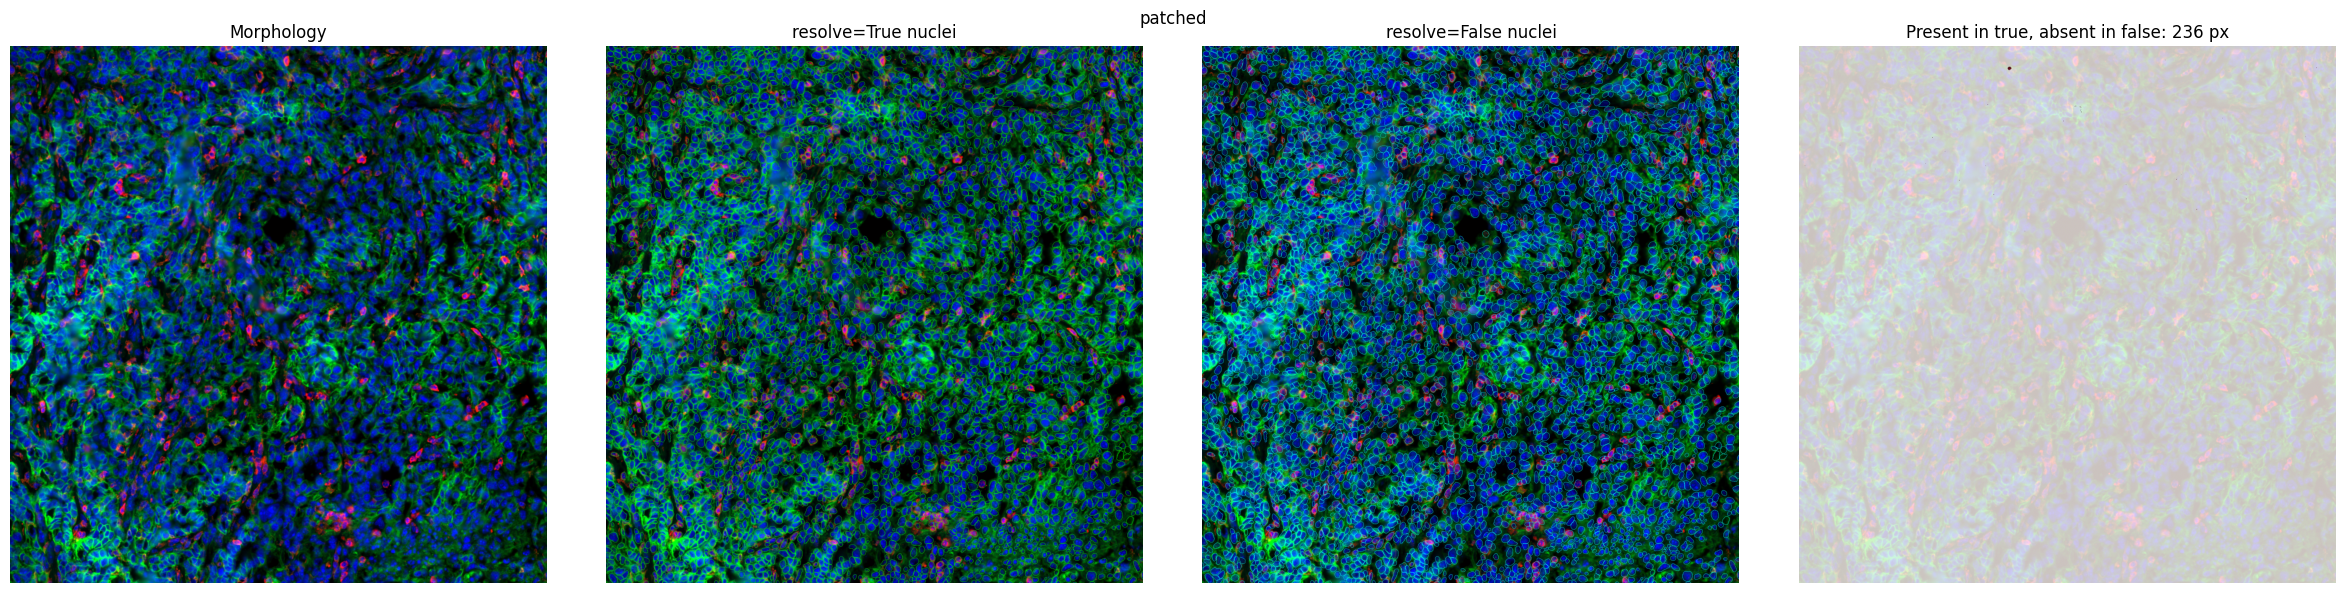

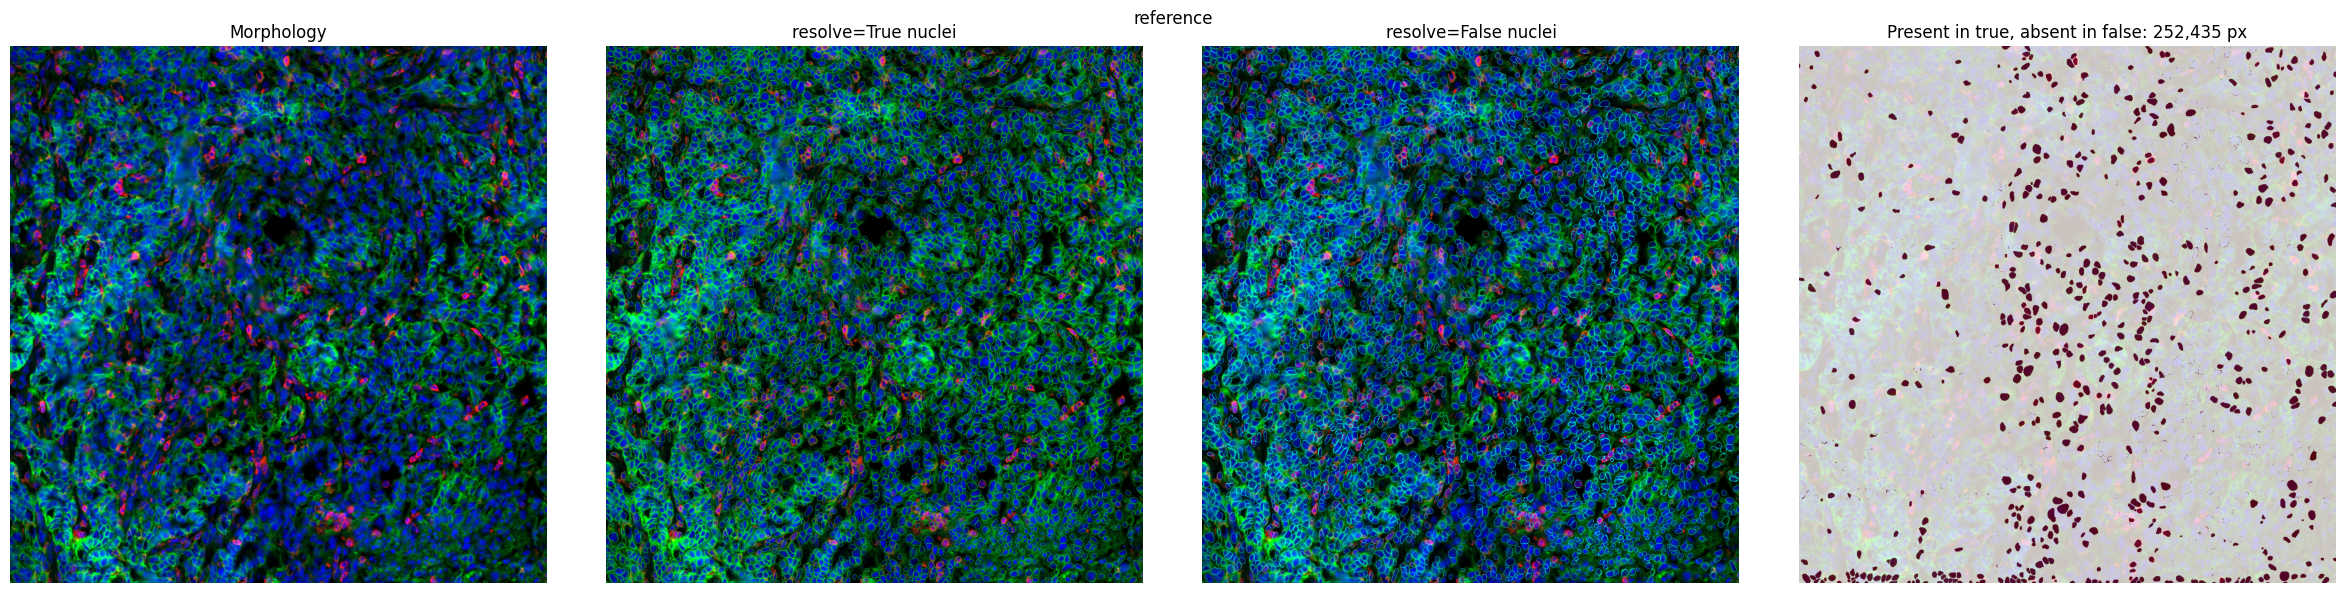

In [9]:
def count_instances(labels):
    return int(np.unique(labels[labels > 0]).size)

rows = []
for source, output in results.items():
    for plane, compartment in enumerate(['nuclei', 'cells']):
        resolved = output['resolved'][plane]
        unresolved = output['unresolved'][plane]
        rows.append({
            'source': source,
            'compartment': compartment,
            'resolved_instances': count_instances(resolved),
            'unresolved_instances': count_instances(unresolved),
            'resolved_pixels': int(np.count_nonzero(resolved)),
            'unresolved_pixels': int(np.count_nonzero(unresolved)),
            'resolved_not_unresolved_pixels': int(np.count_nonzero((resolved > 0) & (unresolved == 0))),
            'unresolved_not_resolved_pixels': int(np.count_nonzero((unresolved > 0) & (resolved == 0))),
        })
summary = pd.DataFrame(rows)
if not summary.empty:
    display(summary)

def overlay(image, labels, color):
    shown = image.copy()
    shown[find_boundaries(labels, mode='outer')] = color
    return shown

VIEW = (slice(0, rgb.shape[0]), slice(0, rgb.shape[1]))  # Edit for a zoomed view.
for source, output in results.items():
    resolved_nuclei = output['resolved'][0]
    unresolved_nuclei = output['unresolved'][0]
    missing = (resolved_nuclei > 0) & (unresolved_nuclei == 0)
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(rgb[VIEW]); axes[0].set_title('Morphology')
    axes[1].imshow(overlay(rgb, resolved_nuclei, (0, 1, 0))[VIEW]); axes[1].set_title('resolve=True nuclei')
    axes[2].imshow(overlay(rgb, unresolved_nuclei, (0, 1, 1))[VIEW]); axes[2].set_title('resolve=False nuclei')
    axes[3].imshow(rgb[VIEW]); axes[3].imshow(missing[VIEW], cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[3].set_title(f'Present in true, absent in false: {missing.sum():,} px')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(source)
    plt.tight_layout(); plt.show()

Direct resolve=False nuclear comparison
  foreground pixels restored by patch: 253456
  foreground pixels present only in reference: 520


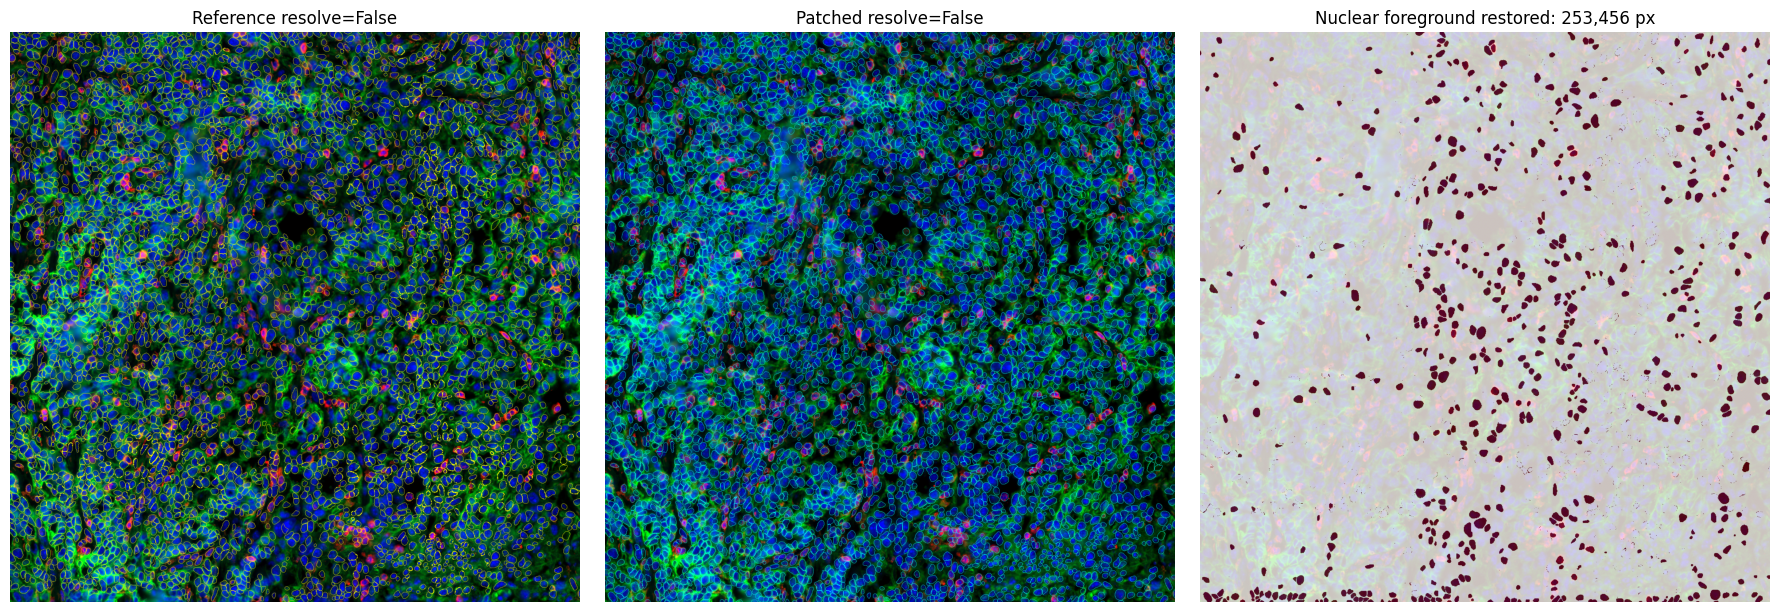

In [10]:
if {'patched', 'reference'} <= results.keys():
    patched_false = results['patched']['unresolved'][0]
    reference_false = results['reference']['unresolved'][0]
    restored = (patched_false > 0) & (reference_false == 0)
    removed = (patched_false == 0) & (reference_false > 0)
    print('Direct resolve=False nuclear comparison')
    print('  foreground pixels restored by patch:', int(restored.sum()))
    print('  foreground pixels present only in reference:', int(removed.sum()))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(overlay(rgb, reference_false, (1, 1, 0))[VIEW]); axes[0].set_title('Reference resolve=False')
    axes[1].imshow(overlay(rgb, patched_false, (0, 1, 1))[VIEW]); axes[1].set_title('Patched resolve=False')
    axes[2].imshow(rgb[VIEW]); axes[2].imshow(restored[VIEW], cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[2].set_title(f'Nuclear foreground restored: {restored.sum():,} px')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout(); plt.show()